# Fat Tails for Quants — Cauchy, Student's *t*, and Kurtosis

> *"In the market, the rare event is not rare."*

If you are interviewing at a quantitative trading firm, you **will** be asked about fat tails. The single most important empirical fact in finance is this: **asset returns are not Normal.** Big moves — crashes, gaps, melt-ups — happen far more often than a bell curve predicts. The mathematical language for describing *how much* a distribution misbehaves in the tails is built from three ideas:

| Idea | One-line meaning |
| --- | --- |
| **Kurtosis** | A number that measures how heavy the tails are |
| **Cauchy distribution** | The pathological extreme — tails so heavy the *mean itself doesn't exist* |
| **Student's *t* distribution** | The practical workhorse — a dial that smoothly goes from Cauchy (wild) to Normal (tame) |

This notebook builds all three from first principles, with code you can run and pictures you can stare at. The recurring question we keep in mind: **"If I assume Normal returns and the world is actually fat-tailed, how badly do I get hurt?"**

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(7)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f8",
    "axes.grid":        True,
    "grid.color":       "white",
    "grid.linewidth":   1.2,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.family":      "sans-serif",
})

# A consistent color language used throughout the notebook:
C_NORMAL = "steelblue"     # the tame, well-behaved baseline
C_CAUCHY = "tomato"        # the wild, pathological extreme
C_T      = "mediumseagreen"
C_ACCENT = "darkorange"
C_DARK   = "navy"


## 1 · Why a trader cares: a 5-second demo

Before any math, let's *feel* the problem. We draw samples from two distributions that look almost identical in the middle, then ask: **how big is the worst draw out of 10,000?**

- **Normal(0, 1)** — the textbook bell curve.
- **Student's *t* with 3 degrees of freedom** — same center, similar shoulders, but fatter tails.

Imagine each sample is a daily return (in "sigmas"). The Normal world is the one your risk model assumes. The *t* world is closer to reality.

In [2]:
N = 10_000
normal_draws = rng.standard_normal(N)
t_draws      = rng.standard_t(df=3, size=N)

print(f"{'':16s}{'Normal(0,1)':>14s}{'Student-t(df=3)':>18s}")
print(f"{'std dev':16s}{normal_draws.std():14.2f}{t_draws.std():18.2f}")
print(f"{'worst (min)':16s}{normal_draws.min():14.2f}{t_draws.min():18.2f}")
print(f"{'best (max)':16s}{normal_draws.max():14.2f}{t_draws.max():18.2f}")
print(f"{'# beyond 5 sigma':16s}{np.sum(np.abs(normal_draws) > 5):14d}{np.sum(np.abs(t_draws) > 5):18d}")


                   Normal(0,1)   Student-t(df=3)
std dev                   0.99              1.74
worst (min)              -3.66            -24.74
best (max)                4.06             32.14
# beyond 5 sigma             0               169


Run it and look at the last row. Under the Normal, a move beyond **5 standard deviations** is essentially a once-in-a-million-day event (you'll usually see **0** of them). Under *t*(3), with the *same standard deviation*, you'll see a handful — every single run.

> **Key insight:** Two distributions can share the same mean and variance yet have wildly different risk. Standard deviation is blind to the tails. We need a tool that *sees* the tails — that tool is **kurtosis**.

---

## 2 · Moments — the DNA of a distribution

To talk about tails precisely, we need **moments**. A moment is just an *average of a power* of the (centered, scaled) data. Each higher power exaggerates large values more, so each moment "zooms in" further on the tails.

Let $X$ be a random variable with mean $\mu$ and standard deviation $\sigma$. Define the **standardized variable**

$$ z = \frac{X - \mu}{\sigma} $$

This recenters to 0 and rescales to unit spread, so we're comparing *shape*, not location or scale. The moments of $z$ are:

| Moment | Formula | What it measures | Analogy |
| --- | --- | --- | --- |
| 1st | $\mathbb{E}[z] = 0$ | center (zero by construction) | where the seesaw balances |
| 2nd | $\mathbb{E}[z^2] = 1$ | spread (one by construction) | how spread out the kids are |
| 3rd | $\mathbb{E}[z^3]$ = **skewness** | left/right asymmetry | is the seesaw lopsided? |
| 4th | $\mathbb{E}[z^4]$ = **kurtosis** | tail heaviness + peakedness | how often a kid flies way off the end |

The key is the **power**. When you raise $z$ to the 4th power, a routine value like $z=1$ contributes $1$, but a tail value like $z=5$ contributes $5^4 = 625$. The 4th moment is dominated by rare, extreme observations — exactly the trader's nightmare scenarios. That's why kurtosis is *the* tail statistic.

$$ \boxed{\;\text{Kurtosis} \;=\; \mathbb{E}\!\left[\left(\frac{X-\mu}{\sigma}\right)^{4}\right]\;} $$

---

## 3 · Kurtosis from scratch

Let's compute kurtosis ourselves so there's no black box. The recipe mirrors the formula exactly:

1. center the data: $X - \mu$
2. scale by $\sigma$: divide by the standard deviation
3. raise to the 4th power
4. average

**Excess kurtosis** subtracts 3, because a Normal distribution has kurtosis exactly **3**. Using the Normal as the "zero point" makes the number interpretable:

$$ \text{excess kurtosis} = \mathbb{E}[z^4] - 3 $$

- excess $= 0$  → tails like a Normal (**mesokurtic**)
- excess $> 0$  → fatter tails than Normal (**leptokurtic**) — the dangerous regime for traders
- excess $< 0$  → thinner tails than Normal (**platykurtic**)

In [3]:
def kurtosis(x, excess=True):
    '''Kurtosis from first principles: mean of the 4th power of standardized data.'''
    x = np.asarray(x, dtype=float)
    z = (x - x.mean()) / x.std()      # standardize: center then scale
    k = np.mean(z**4)                 # 4th moment
    return k - 3.0 if excess else k

# Sanity check against scipy on a large Normal sample
big_normal = rng.standard_normal(2_000_000)
print(f"our excess kurtosis : {kurtosis(big_normal):.4f}")
print(f"scipy excess kurtosis: {stats.kurtosis(big_normal):.4f}")
print(f"(both should be near 0 because Normal has raw kurtosis 3)")


our excess kurtosis : -0.0005
scipy excess kurtosis: -0.0005
(both should be near 0 because Normal has raw kurtosis 3)


Now compare a few distributions on equal footing — every one is standardized, so any difference is *pure shape*.

In [4]:
samples = {
    "Normal":          rng.standard_normal(500_000),
    "Uniform":         rng.uniform(-1, 1, 500_000),
    "Student-t(df=5)": rng.standard_t(5, 500_000),
    "Laplace":         rng.laplace(0, 1, 500_000),
}

print(f"{'distribution':18s}{'excess kurtosis':>18s}   verdict")
print("-" * 60)
for name, s in samples.items():
    ek = kurtosis(s)
    verdict = "fat tails" if ek > 0.3 else ("thin tails" if ek < -0.3 else "~Normal tails")
    print(f"{name:18s}{ek:18.2f}   {verdict}")


distribution         excess kurtosis   verdict
------------------------------------------------------------
Normal                          0.00   ~Normal tails
Uniform                        -1.20   thin tails
Student-t(df=5)                 4.71   fat tails
Laplace                         2.93   fat tails


The Uniform distribution literally *cannot* produce an outlier (it's bounded), so its excess kurtosis is negative. The Laplace (double-exponential) and *t* have pointy peaks **and** fat tails — the leptokurtic signature you see in real returns.

---

## 4 · Seeing kurtosis: it's a tail story, not a peak story

A common interview trap: *"Kurtosis measures peakedness, right?"* Partially — but the 4th-moment weighting means kurtosis is overwhelmingly about the **tails**. Two distributions can have the same peak height and very different kurtosis purely because of what happens far from the center.

The plot below shows three standardized distributions. The **left panel** (linear scale) makes them look almost the same. The **right panel** (log scale on the y-axis) reveals the truth: the tails fan out dramatically. *Log scale is how a quant should always look at return distributions* — it turns invisible tail risk into something you can read off the page.

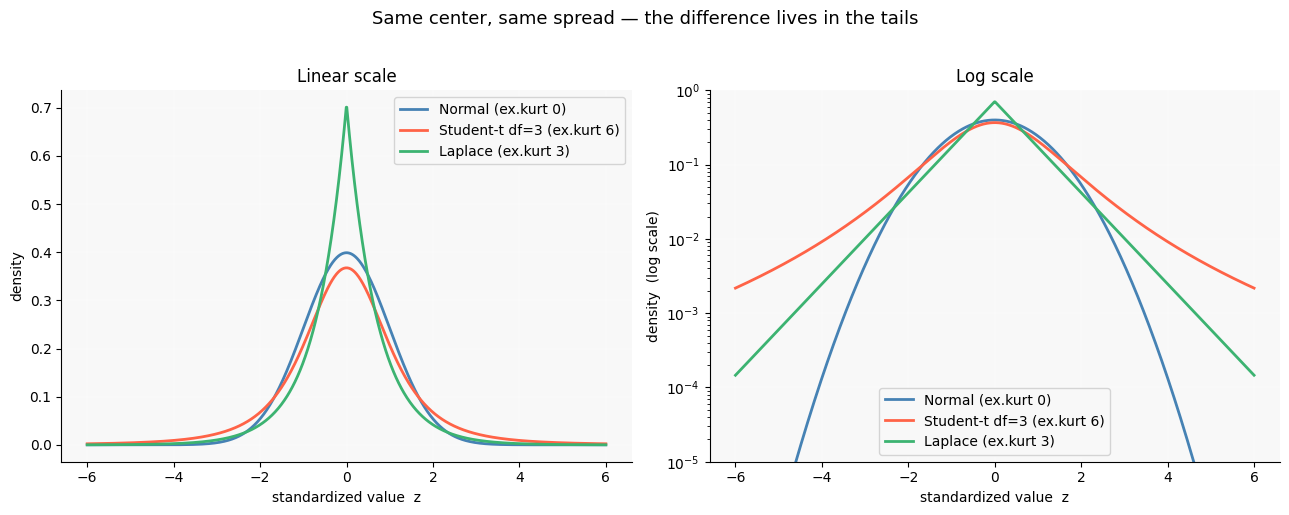

In [5]:
xs = np.linspace(-6, 6, 1000)
pdf_normal = stats.norm.pdf(xs)
pdf_t3     = stats.t.pdf(xs, df=3)
pdf_laplace = stats.laplace.pdf(xs, scale=1/np.sqrt(2))  # scaled to unit variance

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, scale in zip((ax1, ax2), ("linear", "log")):
    ax.plot(xs, pdf_normal,  color=C_NORMAL, lw=2, label="Normal (ex.kurt 0)")
    ax.plot(xs, pdf_t3,      color=C_CAUCHY, lw=2, label="Student-t df=3 (ex.kurt 6)")
    ax.plot(xs, pdf_laplace, color=C_T,      lw=2, label="Laplace (ex.kurt 3)")
    ax.set_yscale(scale)
    ax.set_xlabel("standardized value  z")
    ax.set_ylabel("density" + ("  (log scale)" if scale == "log" else ""))
    ax.set_title(f"{scale.capitalize()} scale")
    ax.legend()
    ax.grid(alpha=0.3)

if True:
    ax2.set_ylim(1e-5, 1)
plt.suptitle("Same center, same spread — the difference lives in the tails", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


> **Key insight:** On the linear plot the curves nearly overlap. On the log plot, the *t*(3) tail sits **orders of magnitude** above the Normal tail at $z = \pm 5$. That vertical gap *is* the excess kurtosis. It is also, literally, the probability of a margin call your Normal model never saw coming.

---

## 5 · The Cauchy distribution — when the mean doesn't exist

Now the extreme case. The **Cauchy distribution** is the poster child for "things break." Its probability density function is

$$ f(x; x_0, \gamma) = \frac{1}{\pi \gamma \left[1 + \left(\dfrac{x - x_0}{\gamma}\right)^{2}\right]} $$

| Symbol | Meaning |
| --- | --- |
| $x_0$ | location (the peak / median) |
| $\gamma$ | scale (half-width at half-maximum — how wide the hump is) |
| $\pi$ | normalizing constant so the area integrates to 1 |

The standard Cauchy ($x_0=0,\ \gamma=1$) is $f(x) = \dfrac{1}{\pi(1+x^2)}$.

**Why it's special.** Look at the tail: for large $x$, $f(x) \sim \dfrac{1}{\pi x^2}$. It decays like $1/x^2$ — *polynomially*, not exponentially like the Normal's $e^{-x^2/2}$. That power-law tail is so heavy that the defining integral for the mean,

$$ \mathbb{E}[X] = \int_{-\infty}^{\infty} x \cdot \frac{1}{\pi(1+x^2)}\, dx, $$

**does not converge.** The integrand behaves like $\frac{x}{\pi x^2} = \frac{1}{\pi x}$ in the tails, and $\int \frac{1}{x}\,dx$ diverges (logarithmically) on each side. The two infinities don't cancel into a finite answer — they cancel into *undefined*. So:

> **Key insight:** A Cauchy random variable has **no mean** and **no variance** (and hence no defined skewness or kurtosis — they're all infinite/undefined). Every moment of order $\geq 1$ blows up. This is the mathematical limit of "fat tails."

Why should a trader care about something so pathological? Because the Cauchy is what you get from an utterly natural operation, as we'll see next — and because it is the warning sign of what happens when tails get too heavy: **your sample averages stop meaning anything.**

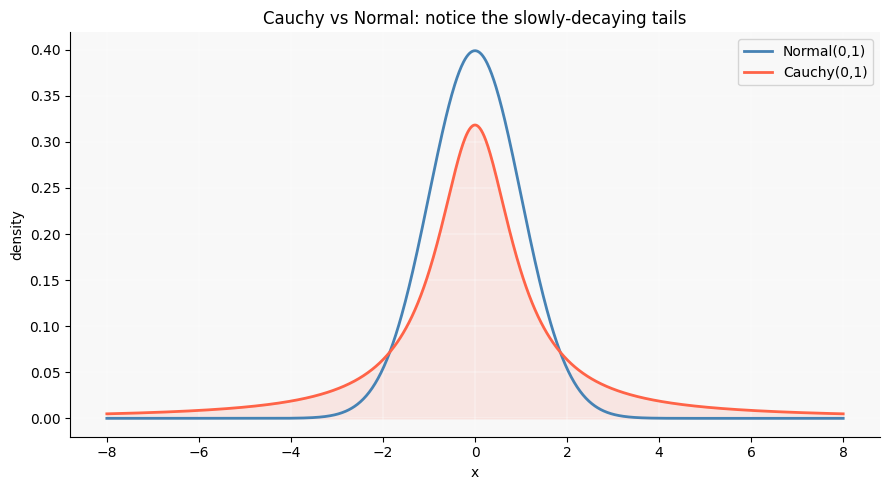

In [6]:
# Cauchy pdf from scratch and verify against scipy
def cauchy_pdf(x, x0=0.0, gamma=1.0):
    return 1.0 / (np.pi * gamma * (1.0 + ((x - x0) / gamma)**2))

xs = np.linspace(-8, 8, 1000)
assert np.allclose(cauchy_pdf(xs), stats.cauchy.pdf(xs)), "should match scipy"

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(xs, stats.norm.pdf(xs),   color=C_NORMAL, lw=2, label="Normal(0,1)")
ax.plot(xs, cauchy_pdf(xs),       color=C_CAUCHY, lw=2, label="Cauchy(0,1)")
ax.fill_between(xs, cauchy_pdf(xs), color=C_CAUCHY, alpha=0.12)
ax.set_xlabel("x"); ax.set_ylabel("density")
ax.set_title("Cauchy vs Normal: notice the slowly-decaying tails")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---

## 6 · Where Cauchy comes from: the ratio of two Normals

Here's the punchline that makes Cauchy relevant to trading. **If $A$ and $B$ are independent standard Normals, then the ratio $A/B$ is Cauchy distributed.**

This is not a curiosity. Ratios are *everywhere* in finance:

- relative value: price of asset A divided by price of asset B
- a regression slope (estimate / estimate)
- a hedge ratio, a beta, a "cheapness" ratio

Whenever you divide one noisy estimate by another noisy estimate that can be near zero, you risk summoning a Cauchy — and with it, infinite variance. The intuition: when the denominator $B$ lands near 0, the ratio explodes to a huge value. Because $B$ has real probability mass near 0, these explosions happen often enough to create the power-law tail.

Let's verify it empirically.

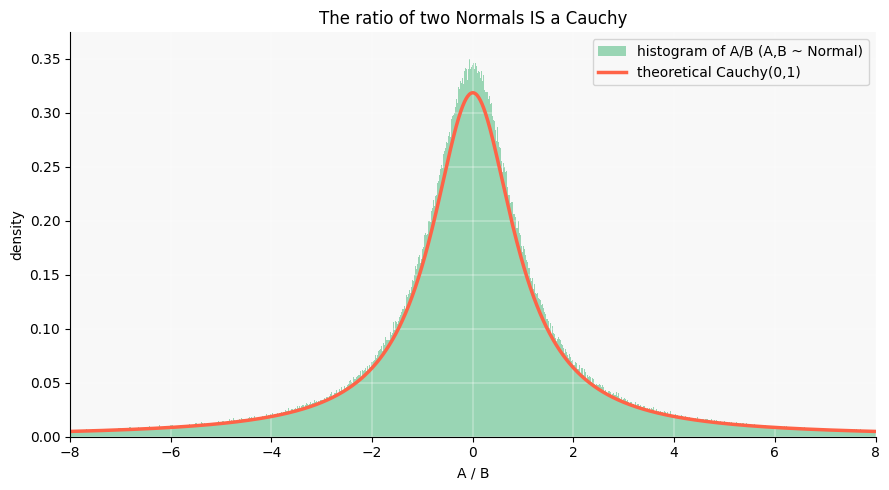

In [7]:
A = rng.standard_normal(2_000_000)
B = rng.standard_normal(2_000_000)
ratio = A / B

xs = np.linspace(-8, 8, 1000)
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(ratio, bins=2000, range=(-8, 8), density=True,
        color=C_T, alpha=0.5, label="histogram of A/B (A,B ~ Normal)")
ax.plot(xs, cauchy_pdf(xs), color=C_CAUCHY, lw=2.5, label="theoretical Cauchy(0,1)")
ax.set_xlim(-8, 8)
ax.set_xlabel("A / B"); ax.set_ylabel("density")
ax.set_title("The ratio of two Normals IS a Cauchy")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


> **Key insight:** Dividing two well-behaved (thin-tailed) quantities can manufacture a monster with no mean and no variance. Any time your strategy or risk metric is a *ratio*, ask yourself whether the denominator can get close to zero. If it can, your nice Normal intuition is gone.

---

## 7 · The Law of Large Numbers breaks for Cauchy

This is the most important — and most testable — consequence. For any distribution with a finite mean, the **Law of Large Numbers** says the running sample average $\bar{X}_n$ converges to the true mean as you collect more data. More data = more certainty. This is the bedrock under almost every statistical estimate a quant makes.

**For the Cauchy, it fails completely.** Because there is no mean to converge to, the running average never settles. In fact a beautiful theorem says: *the average of $n$ i.i.d. Cauchy variables is itself Cauchy with the exact same scale* — averaging buys you **nothing**. A million samples are no more informative about the "center" than one sample.

Let's watch the running average of Normal vs Cauchy samples.

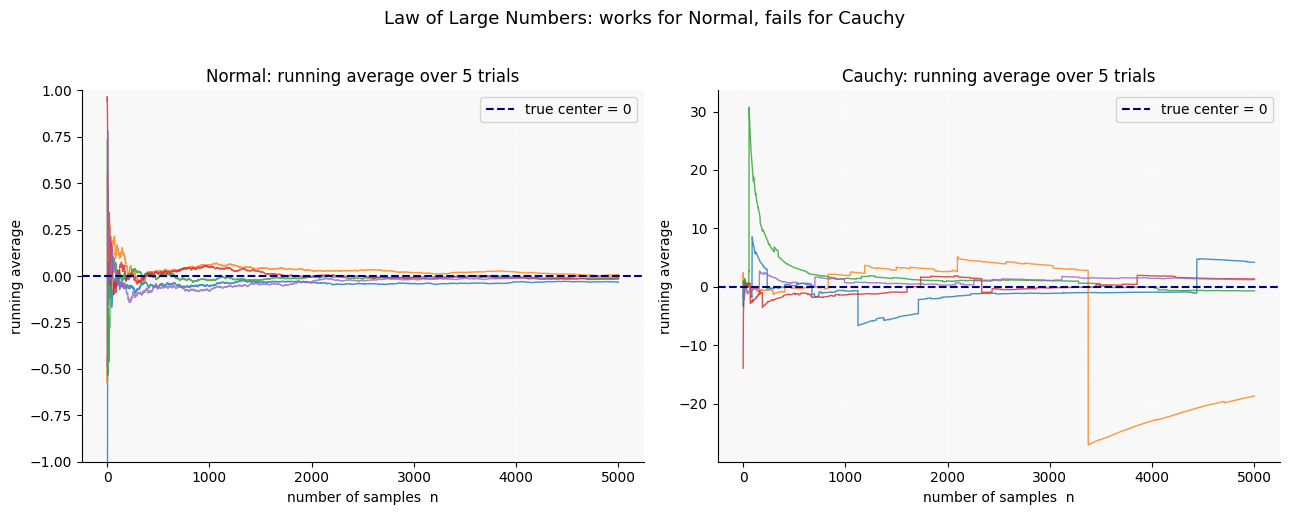

In [8]:
n = 5000
idx = np.arange(1, n + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

for ax, dist, color, name in [
    (ax1, rng.standard_normal,        C_NORMAL, "Normal"),
    (ax2, stats.cauchy.rvs,           C_CAUCHY, "Cauchy"),
]:
    for trial in range(5):
        if name == "Normal":
            x = dist(n)
        else:
            x = dist(size=n, random_state=rng)
        running_mean = np.cumsum(x) / idx
        ax.plot(idx, running_mean, lw=1, alpha=0.8)
    ax.axhline(0, color=C_DARK, ls="--", lw=1.5, label="true center = 0")
    ax.set_xlabel("number of samples  n")
    ax.set_ylabel("running average")
    ax.set_title(f"{name}: running average over 5 trials")
    ax.legend(); ax.grid(alpha=0.3)

ax1.set_ylim(-1, 1)   # Normal: zoom in, it hugs zero
plt.suptitle("Law of Large Numbers: works for Normal, fails for Cauchy", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()


The left panel: every Normal trial homes in on 0 — that's the LLN doing its job. The right panel: the Cauchy averages jump around forever, with violent jolts each time a giant outlier lands. **The average of 5000 Cauchy samples can be just as far from 0 as a single sample.**

> **Interview gold:** *"What happens to the sample mean of Cauchy data as $n \to \infty$?"* — It does **not** converge. The sample mean of $n$ Cauchys is distributed exactly like a single Cauchy. The Central Limit Theorem also does not apply (it requires finite variance). This is why, with truly fat-tailed data, the **median** (which is well-defined and robust) is a far safer estimate of center than the mean.

---

## 8 · Student's *t* — the dial between Cauchy and Normal

The Cauchy is too wild and the Normal is too tame. Reality lives in between — and that's exactly where **Student's *t* distribution** sits. It has one shape parameter, the **degrees of freedom** $\nu$ (nu), that acts as a *fat-tail dial*:

$$ f(t; \nu) = \frac{\Gamma\!\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu \pi}\,\Gamma\!\left(\frac{\nu}{2}\right)} \left(1 + \frac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}} $$

Don't be scared by the $\Gamma$ (gamma) functions out front — they are just a **normalizing constant** that forces the area to equal 1. All the *shape* lives in the right-hand factor:

$$ \left(1 + \frac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}} $$

Here's the intuition for the dial:

- **$\nu = 1$:** the exponent and the $1+t^2/\nu$ term collapse to exactly the Cauchy form. **Student-t(1) = Cauchy.** Maximum fatness.
- **$\nu \to \infty$:** the term $\left(1+\frac{t^2}{\nu}\right)^{-\nu/2} \to e^{-t^2/2}$ (a standard calculus limit). **Student-t($\infty$) = Normal.** Tails as thin as they get.
- **In between:** a polynomial (power-law) tail $f(t)\sim |t|^{-(\nu+1)}$ — fatter than Normal, but tamer than Cauchy.

| Symbol | Meaning | Trader's reading |
| --- | --- | --- |
| $\nu$ (df) | degrees of freedom | the fat-tail dial: low = scary, high = calm |
| $t$ | the value | a return in "sigma" units |
| $\Gamma$ | gamma function (generalized factorial) | bookkeeping to normalize |

Originally $\nu$ came from sample size in small-sample statistics (Gosset, brewing beer at Guinness, 1908). In quant finance we reinterpret it as a free parameter we *fit* to returns — and empirically, equity index returns often come out around $\nu \approx 3$ to $5$.

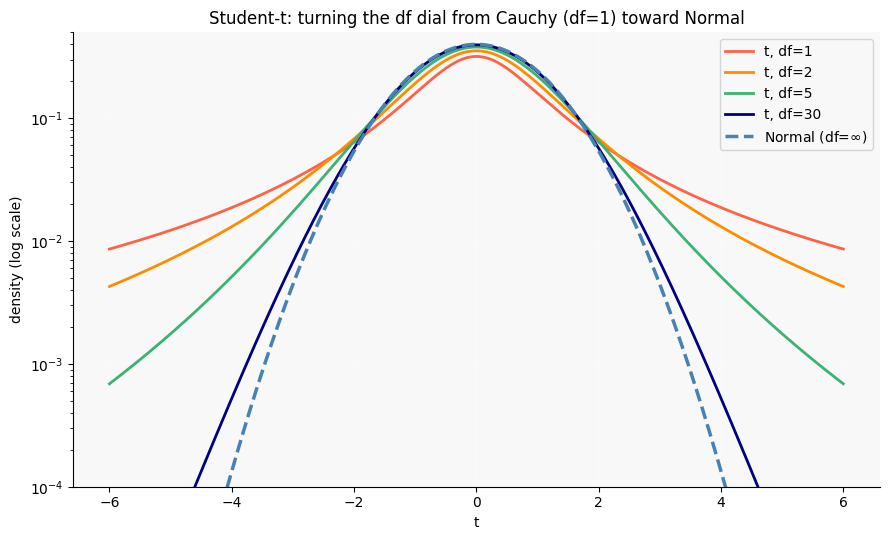

In [9]:
def student_t_pdf(t, nu):
    '''Student-t pdf from scratch using the gamma function.'''
    from scipy.special import gamma
    norm_const = gamma((nu + 1) / 2) / (np.sqrt(nu * np.pi) * gamma(nu / 2))
    return norm_const * (1 + t**2 / nu) ** (-(nu + 1) / 2)

ts = np.linspace(-6, 6, 1000)
assert np.allclose(student_t_pdf(ts, 4), stats.t.pdf(ts, df=4)), "matches scipy"

fig, ax = plt.subplots(figsize=(9, 5.5))
for nu, col in [(1, C_CAUCHY), (2, C_ACCENT), (5, C_T), (30, C_DARK)]:
    ax.plot(ts, student_t_pdf(ts, nu), color=col, lw=2, label=f"t, df={nu}")
ax.plot(ts, stats.norm.pdf(ts), color=C_NORMAL, lw=2.5, ls="--", label="Normal (df=$\\infty$)")
ax.set_yscale("log"); ax.set_ylim(1e-4, 0.5)
ax.set_xlabel("t"); ax.set_ylabel("density (log scale)")
ax.set_title("Student-t: turning the df dial from Cauchy (df=1) toward Normal")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


On the log scale you can read the dial directly: **df=1 (Cauchy, red)** has the highest tail, and as df grows the tail drops toward the dashed Normal. By df=30 it's almost indistinguishable from Normal.

---

## 9 · Kurtosis of the *t*: the dial, quantified

The *t* distribution lets us connect everything back to kurtosis with an exact formula. For $\nu > 4$, the **excess kurtosis** of Student's *t* is

$$ \text{excess kurtosis} = \frac{6}{\nu - 4} $$

Read this formula like a story:

- As $\nu \to \infty$: $\frac{6}{\nu-4} \to 0$ → matches the Normal. ✓
- As $\nu \to 4^{+}$: it blows up to $+\infty$ → tails getting dangerously heavy.
- **For $\nu \le 4$: kurtosis is infinite/undefined** — the 4th moment integral diverges, just like the whole Cauchy did.
- **For $\nu \le 2$: even the variance is infinite.** At $\nu=1$ we're back to Cauchy with no mean at all.

So the single dial $\nu$ controls *which moments even exist*:

| df $\nu$ | mean? | variance? | kurtosis? | character |
| --- | --- | --- | --- | --- |
| 1 (Cauchy) | ✗ | ✗ | ✗ | pathological |
| 2 | ✓ | ✗ | ✗ | infinite variance |
| 3 | ✓ | ✓ | ✗ | finite var, infinite kurtosis |
| 5 | ✓ | ✓ | ✓ (=6) | very fat but all defined |
| 30 | ✓ | ✓ | ✓ (≈0.23) | nearly Normal |

Let's confirm the formula empirically (for $\nu > 4$, where it's finite).

In [10]:
print(f"{'df':>4s}{'theory 6/(nu-4)':>18s}{'empirical (5M draws)':>22s}")
print("-" * 46)
for nu in [5, 6, 8, 12, 30]:
    theory = 6 / (nu - 4)
    sample = stats.t.rvs(df=nu, size=5_000_000, random_state=rng)
    print(f"{nu:>4d}{theory:>18.3f}{kurtosis(sample):>22.3f}")
print("\n(for df <= 4 the empirical estimate is unstable because the true value is infinite)")


  df   theory 6/(nu-4)  empirical (5M draws)
----------------------------------------------
   5             6.000                 4.815
   6             3.000                 2.882
   8             1.500                 1.501
  12             0.750                 0.765
  30             0.231                 0.232

(for df <= 4 the empirical estimate is unstable because the true value is infinite)


---

## 10 · Putting it to work: fat tails and Value-at-Risk

Time for the application an interviewer actually wants. Suppose daily returns have mean 0 and volatility $\sigma$. We want the **1% Value-at-Risk** — the loss threshold that is breached only 1% of the time (a 1-in-100-day event). The question:

> *"If I assume Normal returns but the world is Student-t, how much do I underestimate my tail risk?"*

We compute the 1st-percentile quantile (the cutoff) under both assumptions, with the **same standard deviation**, so it's an apples-to-apples comparison of pure tail shape.

In [11]:
# Standardize the t so it has unit variance, making the comparison fair.
def t_quantile_unit_var(p, nu):
    raw = stats.t.ppf(p, df=nu)            # quantile of standard t
    scale = np.sqrt(nu / (nu - 2))         # std of standard t (nu>2)
    return raw / scale                     # rescale to unit variance

p = 0.01
z_normal = stats.norm.ppf(p)
print(f"1% quantile under Normal: {z_normal:.2f} sigma\n")
print(f"{'df (nu)':>8s}{'1% VaR (sigma)':>18s}{'vs Normal':>14s}")
print("-" * 40)
for nu in [3, 4, 5, 8, 30]:
    q = t_quantile_unit_var(p, nu)
    print(f"{nu:>8d}{q:>18.2f}{q / z_normal:>13.2f}x")


1% quantile under Normal: -2.33 sigma

 df (nu)    1% VaR (sigma)     vs Normal
----------------------------------------
       3             -2.62         1.13x
       4             -2.65         1.14x
       5             -2.61         1.12x
       8             -2.51         1.08x
      30             -2.37         1.02x


Read the last column: with df=3, your true 1% VaR is roughly **1.5x deeper** than the Normal model claims. If your risk system says "we lose more than \$10M only 1% of the time," the fat-tailed reality might be "\$15M." On the days that matter most, the Normal assumption flatters you — and that gap is where firms blow up.

Now visualize the **tail probabilities** directly: how much more likely is a big loss under *t* than under Normal?

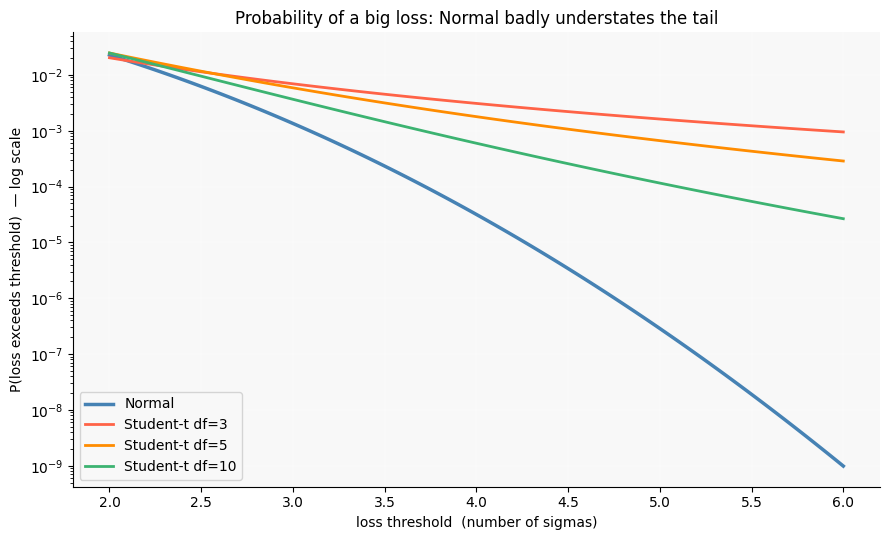

In [12]:
thresholds = np.linspace(2, 6, 100)   # in units of sigma
p_normal = stats.norm.sf(thresholds)  # P(loss beyond k sigma), Normal

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(thresholds, p_normal, color=C_NORMAL, lw=2.5, label="Normal")
for nu, col in [(3, C_CAUCHY), (5, C_ACCENT), (10, C_T)]:
    scale = np.sqrt(nu / (nu - 2))
    p_t = stats.t.sf(thresholds * scale, df=nu)   # unit-variance t tail
    ax.plot(thresholds, p_t, color=col, lw=2, label=f"Student-t df={nu}")

ax.set_yscale("log")
ax.set_xlabel("loss threshold  (number of sigmas)")
ax.set_ylabel("P(loss exceeds threshold)  — log scale")
ax.set_title("Probability of a big loss: Normal badly understates the tail")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


At 4 sigma the gap is already an order of magnitude; by 5-6 sigma the Normal curve has plunged to near-zero while the fat-tailed curves are still meaningfully off the floor. **That vertical gap is unhedged risk you didn't know you had.**

---

## 11 · Interactive — feel the dial yourself

Drag the **degrees-of-freedom** slider and watch three things move together:

1. the **density tail** (log scale),
2. the **excess kurtosis** number,
3. the **1% VaR multiple** vs the Normal.

Watch what happens as you slide toward df=1 (Cauchy) versus df=40 (≈Normal). Notice how the kurtosis label switches to "∞ (undefined)" once you cross df≤4 — the math literally stops having a finite 4th moment.

In [ ]:
try:
    from ipywidgets import interact, IntSlider

    ts = np.linspace(-6, 6, 600)
    pdf_n = stats.norm.pdf(ts)

    def explore(nu=3):
        fig, ax = plt.subplots(figsize=(9, 5.5))
        ax.plot(ts, pdf_n, color=C_NORMAL, lw=2.5, ls="--", label="Normal")
        ax.plot(ts, stats.t.pdf(ts, df=nu), color=C_CAUCHY, lw=2.5, label=f"Student-t df={nu}")
        ax.set_yscale("log"); ax.set_ylim(1e-4, 0.5)
        ax.set_xlabel("t"); ax.set_ylabel("density (log scale)")

        ek = "$\\infty$ (undefined)" if nu <= 4 else f"{6/(nu-4):.2f}"
        if nu > 2:
            scale = np.sqrt(nu / (nu - 2))
            var_mult = f"{stats.t.ppf(0.01, df=nu)/scale / stats.norm.ppf(0.01):.2f}x"
        else:
            var_mult = "huge (var = $\\infty$)"
        ax.set_title(f"df={nu}   |   excess kurtosis = {ek}   |   1% VaR = {var_mult} of Normal")
        ax.legend(); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

    interact(explore, nu=IntSlider(min=1, max=40, step=1, value=3, description="df (nu)"))
except Exception as e:
    print("ipywidgets not available — showing a static df=3 snapshot instead.")
    print(f"({type(e).__name__}: {e})")
    fig, ax = plt.subplots(figsize=(9, 5))
    ts = np.linspace(-6, 6, 600)
    ax.plot(ts, stats.norm.pdf(ts), color=C_NORMAL, lw=2.5, ls="--", label="Normal")
    ax.plot(ts, stats.t.pdf(ts, df=3), color=C_CAUCHY, lw=2.5, label="Student-t df=3")
    ax.set_yscale("log"); ax.set_ylim(1e-4, 0.5)
    ax.set_xlabel("t"); ax.set_ylabel("density (log scale)")
    ax.set_title("df=3 snapshot"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


interactive(children=(IntSlider(value=3, description='df (nu)', max=40, min=1), Output()), _dom_classes=('widg…

---

## 12 · Fitting a *t* to "returns" — recovering the dial

Final practical skill: given a stream of returns, **estimate the degrees of freedom**. This is how you'd actually quantify the fat-tailedness of a real asset. We simulate fat-tailed returns from a known df, then fit and see if we recover it. `scipy.stats.t.fit` does maximum-likelihood estimation for us.

true df        : 4
fitted df      : 4.11
sample excess kurtosis: 12.11   (Normal would be 0)


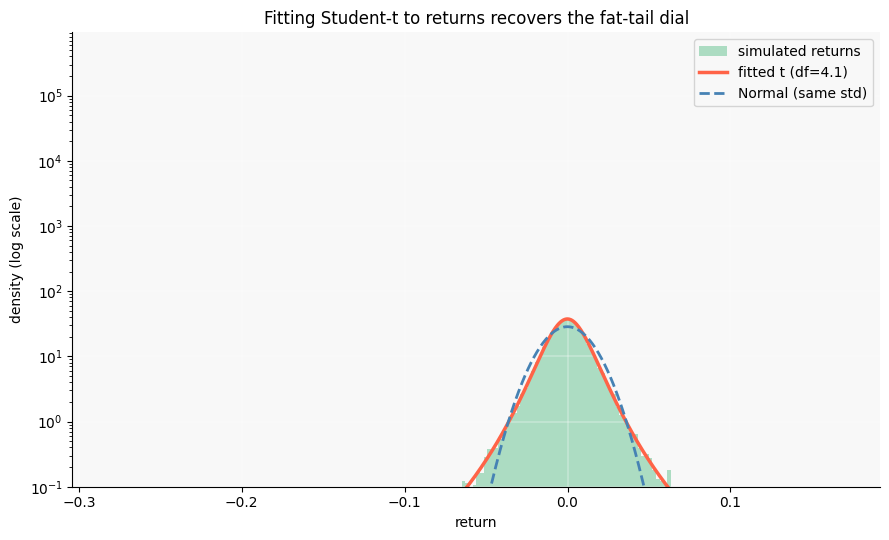

In [14]:
true_nu = 4
returns = stats.t.rvs(df=true_nu, size=50_000, random_state=rng) * 0.01  # ~1% daily scale

fitted_nu, fitted_loc, fitted_scale = stats.t.fit(returns)
print(f"true df        : {true_nu}")
print(f"fitted df      : {fitted_nu:.2f}")
print(f"sample excess kurtosis: {kurtosis(returns):.2f}   (Normal would be 0)")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(returns, bins=200, density=True, color=C_T, alpha=0.4, label="simulated returns")
xs = np.linspace(returns.min(), returns.max(), 1000)
ax.plot(xs, stats.t.pdf(xs, fitted_nu, fitted_loc, fitted_scale),
        color=C_CAUCHY, lw=2.5, label=f"fitted t (df={fitted_nu:.1f})")
# A Normal with the same std, for contrast
ax.plot(xs, stats.norm.pdf(xs, returns.mean(), returns.std()),
        color=C_NORMAL, lw=2, ls="--", label="Normal (same std)")
ax.set_yscale("log"); ax.set_ylim(1e-1, None)
ax.set_xlabel("return"); ax.set_ylabel("density (log scale)")
ax.set_title("Fitting Student-t to returns recovers the fat-tail dial")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


The fitted df lands near the true value, and on the log plot you can *see* the Normal (dashed) diving below the data in the tails while the fitted *t* tracks them. In a real interview, being able to say *"I'd fit a Student-t, the df came out around 4, that's an excess kurtosis of about 3, so my VaR needs a fat-tail adjustment"* is exactly the kind of concrete, quantitative reasoning they're listening for.

---

## 13 · Summary

| Concept | Key Idea |
| --- | --- |
| **Moments** | Averages of powers of standardized data; higher powers weight the tails more heavily. |
| **Kurtosis** | The 4th standardized moment, $\mathbb{E}[z^4]$. Dominated by rare extreme values — it *measures the tails*. |
| **Excess kurtosis** | Kurtosis $-\,3$. Zero = Normal-like; positive (leptokurtic) = fat tails, the trader's risk regime. |
| **Tails, not peaks** | View return distributions on a **log y-axis**; that's where fat tails become visible. |
| **Cauchy distribution** | Power-law $1/x^2$ tails so heavy that **mean and variance don't exist**. The extreme limit of fat tails. |
| **Cauchy = ratio of Normals** | $A/B$ for independent Normals is Cauchy — fat tails appear whenever you divide by something that can be near zero. |
| **LLN breaks for Cauchy** | Sample mean never converges; the mean of $n$ Cauchys is still Cauchy. Use the **median** for fat-tailed data. |
| **Student's *t*** | One dial $\nu$ (df): $\nu=1$ is Cauchy, $\nu\to\infty$ is Normal. Power-law tail $\sim |t|^{-(\nu+1)}$. |
| **t excess kurtosis** | $\dfrac{6}{\nu-4}$ for $\nu>4$; infinite for $\nu\le4$; variance infinite for $\nu\le2$. The dial controls which moments even exist. |
| **Why it matters (VaR)** | Assuming Normal when returns are *t*(3–5) understates tail loss by ~1.5x+ — the gap where portfolios blow up. |
| **Fitting** | `scipy.stats.t.fit` recovers $\nu$ from data; equity returns typically give $\nu \approx 3$–$5$. |

> **The one sentence to remember in the interview:** *Real returns are fat-tailed (high kurtosis); the Student-t with low degrees of freedom models this, the Cauchy is the breaking-point where moments cease to exist, and assuming Normality systematically underprices tail risk.*